In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv('/mnt/c/Users/Leonardo Oliveira/OneDrive/Desktop/leonardo-dev/churn-prediction-ml-platform/.env')

engine = create_engine(
    f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}"
    f"@{os.environ.get('POSTGRES_HOST','localhost')}:{os.environ.get('POSTGRES_PORT','5434')}"
    f"/{os.environ['POSTGRES_DB']}"
)

df = pd.read_sql("SELECT * FROM churn.customers", engine)
print(df.shape)
df.head()


(7043, 38)


,id,tenant_id,project_id,customer_id,customer_count,country,state,city,zip_code,lat_long,...,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason,is_synthetic,created_at
0,2c7a633e-3d26-452b-bf8d-8326e126b17c,297c0e37-87d5-46d5-b7ae-ab1c3ab3ed56,61c68da0-f922-445c-8eeb-92da9b5f109a,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,False,2026-04-29 03:16:57.541673+00:00
1,b64fd8cd-34ea-4d85-a3b9-a538a7c0218f,297c0e37-87d5-46d5-b7ae-ab1c3ab3ed56,61c68da0-f922-445c-8eeb-92da9b5f109a,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,False,2026-04-29 03:16:57.541673+00:00
2,15cd7f0e-773e-4a94-8f61-d1511937bec0,297c0e37-87d5-46d5-b7ae-ab1c3ab3ed56,61c68da0-f922-445c-8eeb-92da9b5f109a,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",...,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,False,2026-04-29 03:16:57.541673+00:00
3,c377bea0-1b7b-4c09-91ca-e9b973b6ec60,297c0e37-87d5-46d5-b7ae-ab1c3ab3ed56,61c68da0-f922-445c-8eeb-92da9b5f109a,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,False,2026-04-29 03:16:57.541673+00:00
4,5a034294-eaee-4bfc-ae57-499ffa223281,297c0e37-87d5-46d5-b7ae-ab1c3ab3ed56,61c68da0-f922-445c-8eeb-92da9b5f109a,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",...,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,False,2026-04-29 03:16:57.541673+00:00


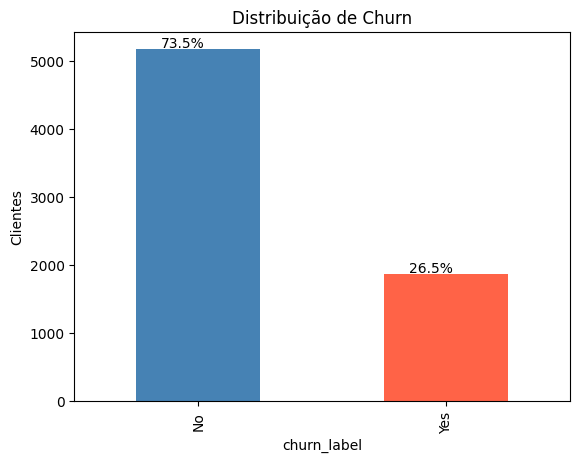

In [3]:
ax = df['churn_label'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
ax.set_title('Distribuição de Churn')
ax.set_ylabel('Clientes')
for p in ax.patches:
    ax.annotate(f'{p.get_height()/len(df):.1%}', (p.get_x()+0.1, p.get_height()+30))
plt.show()


In [4]:
missing = df.isnull().sum()
missing[missing > 0]


total_charges      11
churn_reason     5174
dtype: int64

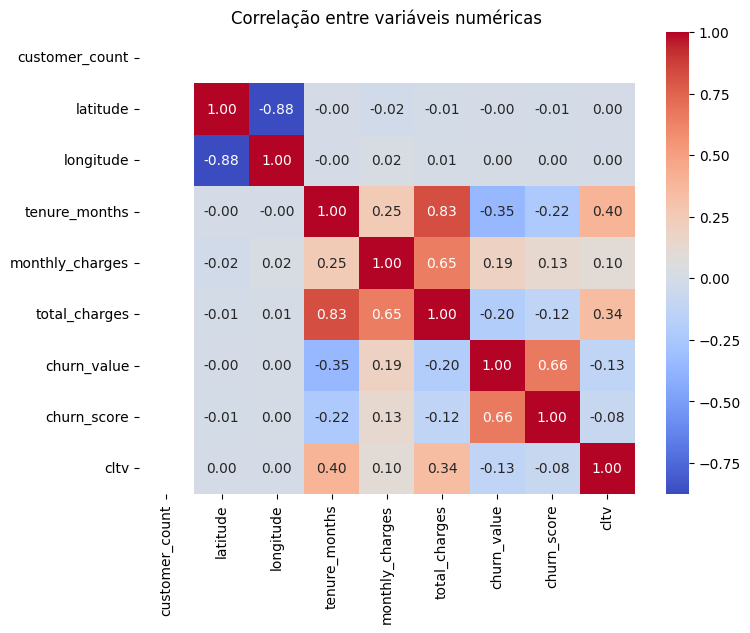

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes('number').corr(),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('Correlação entre variáveis numéricas')
plt.show()

/tmp/ipykernel_5074/756453035.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn_label', y='tenure_months', data=df, palette={'No':'steelblue','Yes':'tomato'})


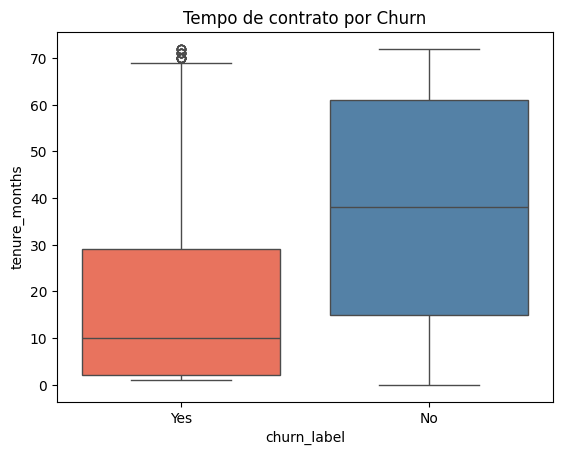

In [7]:
sns.boxplot(x='churn_label', y='tenure_months', data=df, palette={'No':'steelblue','Yes':'tomato'})
plt.title('Tempo de contrato por Churn')
plt.show()

/tmp/ipykernel_5074/3710752708.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn_label', y='cltv', data=df, palette={'No':'steelblue','Yes':'tomato'})


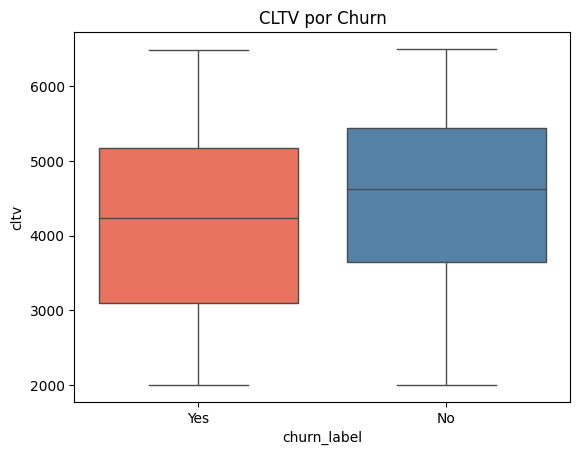

In [8]:
sns.boxplot(x='churn_label', y='cltv', data=df, palette={'No':'steelblue','Yes':'tomato'})
plt.title('CLTV por Churn')
plt.show()

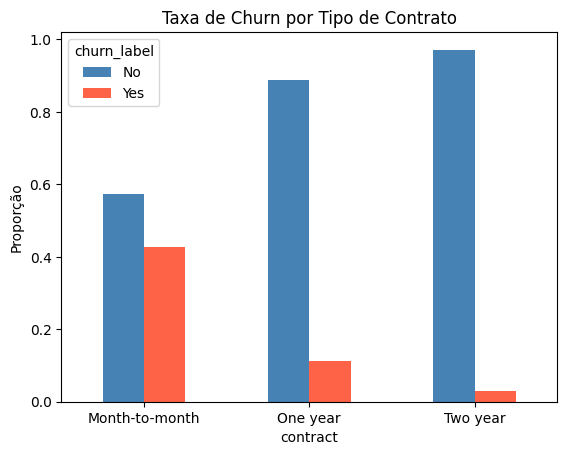

In [9]:
ct = df.groupby(['contract','churn_label']).size().unstack()
ct.div(ct.sum(axis=1), axis=0).plot(kind='bar', color=['steelblue','tomato'])
plt.title('Taxa de Churn por Tipo de Contrato')
plt.ylabel('Proporção')
plt.xticks(rotation=0)
plt.show()

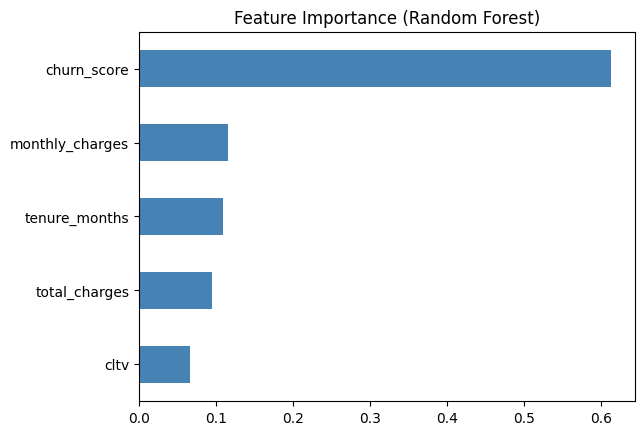

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

features = ['tenure_months','monthly_charges','total_charges','cltv','churn_score']
X = df[features].fillna(0)
y = df['churn_value']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

pd.Series(rf.feature_importances_, index=features)\
  .sort_values()\
  .plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.show()

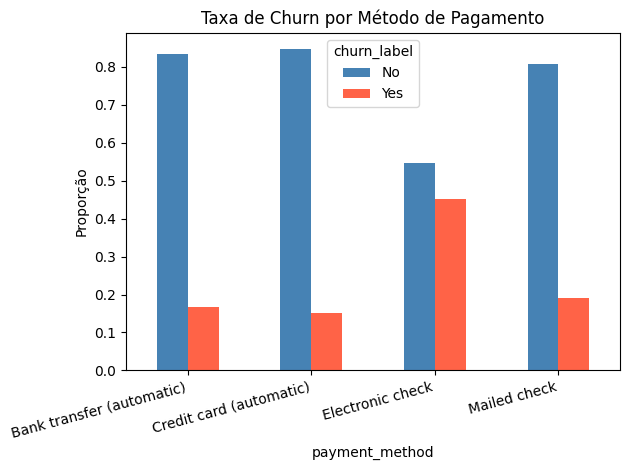

In [11]:
ct = df.groupby(['payment_method','churn_label']).size().unstack()
ct.div(ct.sum(axis=1), axis=0).plot(kind='bar', color=['steelblue','tomato'])
plt.title('Taxa de Churn por Método de Pagamento')
plt.ylabel('Proporção')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


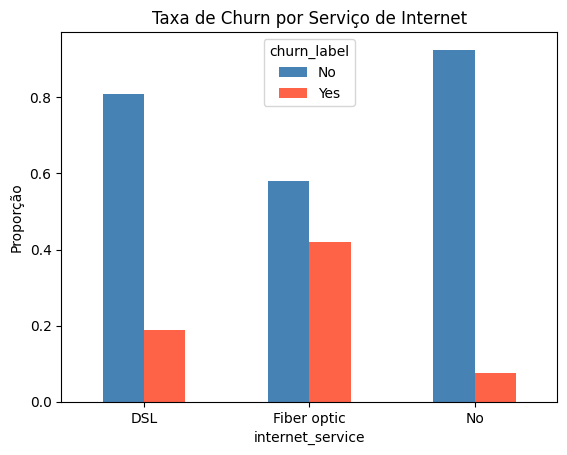

In [12]:
ct = df.groupby(['internet_service','churn_label']).size().unstack()
ct.div(ct.sum(axis=1), axis=0).plot(kind='bar', color=['steelblue','tomato'])
plt.title('Taxa de Churn por Serviço de Internet')
plt.ylabel('Proporção')
plt.xticks(rotation=0)
plt.show()


/tmp/ipykernel_5074/196763073.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn_label', y='monthly_charges', data=df, palette={'No':'steelblue','Yes':'tomato'})


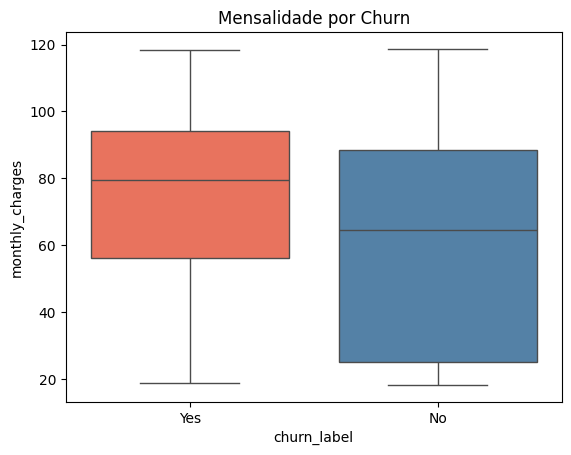

In [13]:
sns.boxplot(x='churn_label', y='monthly_charges', data=df, palette={'No':'steelblue','Yes':'tomato'})
plt.title('Mensalidade por Churn')
plt.show()


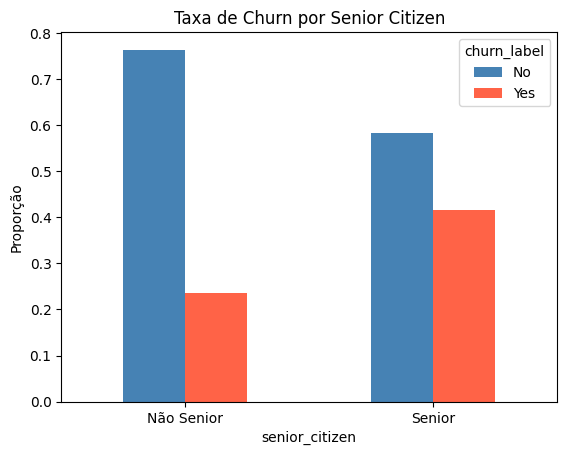

In [14]:
ct = df.groupby(['senior_citizen','churn_label']).size().unstack()
ct.div(ct.sum(axis=1), axis=0).plot(kind='bar', color=['steelblue','tomato'])
plt.title('Taxa de Churn por Senior Citizen')
plt.ylabel('Proporção')
plt.xticks(ticks=[0,1], labels=['Não Senior','Senior'], rotation=0)
plt.show()


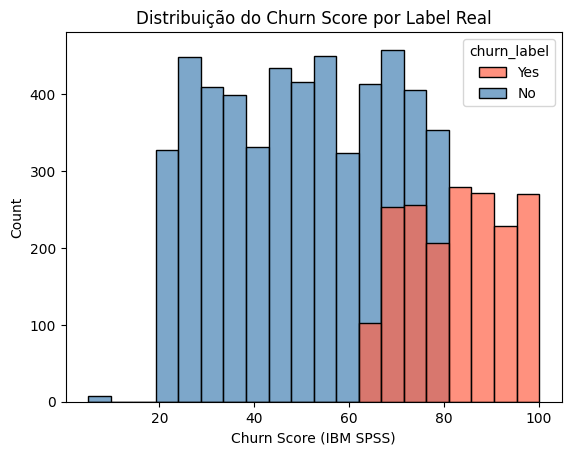

In [15]:
sns.histplot(data=df, x='churn_score', hue='churn_label', bins=20,
             palette={'No':'steelblue','Yes':'tomato'}, alpha=0.7)
plt.title('Distribuição do Churn Score por Label Real')
plt.xlabel('Churn Score (IBM SPSS)')
plt.show()
